In [1]:

import pandas as pd
print("pandas", pd.__version__)

import numpy as np
print("numpy", np.__version__)

import seaborn as sns
print("seaborn", sns.__version__)

import tqdm
print('tqdm', tqdm.__version__)
from tqdm import tqdm 

import matplotlib as mpl
import matplotlib.pyplot as plt
print("matplotlib", mpl.__version__)


from collections import defaultdict, Counter
from glob import glob


pandas 2.2.3
numpy 1.26.4
seaborn 0.13.2
tqdm 4.67.1
matplotlib 3.9.2


In [2]:
ls ../data

ABIOPF004_M01_EXP25000100_TCR_CDS_01APR2025.xlsx
ABIOPF004_M01_EXP25000100_TCR_CDS_03APR2025_11 sticky removed.xlsx
ABIOPF004_M01_EXP25000100_TCR_CDS_and_Oligos-PFO004_Revised_Barcodes_01_Remove_Sticky_02.xlsx
ABIOPF004_M01_EXP25000100_TCR_CDS_and_Oligos-PFO004_Revised_Barcodes_01_Remove_Sticky_03 (11 pairs).xlsx
PFO004.chosen-tcrs.cd4.complete-multi.tier1.preferred-fdr-0.0001.txt
PFO004.chosen-tcrs.cd4.complete-multi.tier2.preferred-fdr-0.001.txt
PFO004.chosen-tcrs.cd4.complete-multi.tier3.preferred-fdr-0.01.txt
PFO004.chosen-tcrs.cd4.complete-multi.tier4.preferred-fdr-0.1.txt
PFO004.chosen-tcrs.cd4.complete-multi.tier5.preferred-fdr-0.15.txt
PFO004.chosen-tcrs.cd4.complete-single.tier1.preferred-fdr-0.0001.txt
PFO004.chosen-tcrs.cd4.complete-single.tier2.preferred-fdr-0.001.txt
PFO004.chosen-tcrs.cd4.complete-single.tier3.preferred-fdr-0.01.txt
PFO004.chosen-tcrs.cd4.complete-single.tier4.preferred-fdr-0.1.txt
PFO004.chosen-tcrs.cd4.complete-single.tier5.preferred-fdr-0.15.txt
PFO004

In [3]:
ls ../data/pfo-lab-tcr-culture/*

../data/pfo-lab-tcr-culture/PFO004-716803-L2-5GEX-lib:
analysis/                      molecule_info.h5_.gstmp
filtered_feature_bc_matrix.h5  raw_feature_bc_matrix.h5
metrics_summary.csv            web_summary.html

../data/pfo-lab-tcr-culture/PFO004-716803-L2-VDJ-lib:
airr_rearrangement.tsv           consensus.fasta.fai
all_contig.fasta                 consensus_annotations.csv
all_contig.fasta.fai             donor_regions.fa
all_contig_annotations.csv       filtered_contig.fasta
clonotypes.csv                   filtered_contig_annotations.csv
concat_ref.fasta                 metrics_summary.csv
concat_ref.fasta.fai             web_summary.html
consensus.fasta

../data/pfo-lab-tcr-culture/PFO004-716803-L3-5GEX-lib:
filtered_feature_bc_matrix.h5  raw_feature_bc_matrix.h5
metrics_summary.csv            web_summary.html
molecule_info.h5_.gstmp

../data/pfo-lab-tcr-culture/PFO004-716803-L3-VDJ-lib:
airr_rearrangement.tsv           consensus.fasta.fai
all_contig.fasta                 conse

In [4]:

# [GEX|TCR] -> condition -> pool -> path
pooled_peptide_dirs = defaultdict(lambda: defaultdict(dict))

for path in glob("../data/pfo-lab-tcr-culture/*"):
    dirname = path.split("/")[-1]
    
 
    parts = dirname.split("-")[:-1]
    data_type = parts[-1]
    pool = parts[-2]
    sample = "-".join(parts[1:-2])
    print(sample, data_type, pool)
    pooled_peptide_dirs[data_type][sample][pool] = path
    
    
pooled_peptide_dirs



820 5GEX L3
820 5GEX L2
716803 VDJ L3
716803 5GEX L2
716803 5GEX L3
Oct-Dec 5GEX L2
Oct-Dec 5GEX L3
716803 VDJ L2
Oct-Dec VDJ L2
Oct-Dec VDJ L3
820 VDJ L3
820 VDJ L2


defaultdict(<function __main__.<lambda>()>,
            {'5GEX': defaultdict(dict,
                         {'820': {'L3': '../data/pfo-lab-tcr-culture/PFO004-820-L3-5GEX-lib',
                           'L2': '../data/pfo-lab-tcr-culture/PFO004-820-L2-5GEX-lib'},
                          '716803': {'L2': '../data/pfo-lab-tcr-culture/PFO004-716803-L2-5GEX-lib',
                           'L3': '../data/pfo-lab-tcr-culture/PFO004-716803-L3-5GEX-lib'},
                          'Oct-Dec': {'L2': '../data/pfo-lab-tcr-culture/PFO004-Oct-Dec-L2-5GEX-lib',
                           'L3': '../data/pfo-lab-tcr-culture/PFO004-Oct-Dec-L3-5GEX-lib'}}),
             'VDJ': defaultdict(dict,
                         {'716803': {'L3': '../data/pfo-lab-tcr-culture/PFO004-716803-L3-VDJ-lib',
                           'L2': '../data/pfo-lab-tcr-culture/PFO004-716803-L2-VDJ-lib'},
                          'Oct-Dec': {'L2': '../data/pfo-lab-tcr-culture/PFO004-Oct-Dec-L2-VDJ-lib',
                    

In [5]:


pool_to_gene_lists = {
    "pool1": ["EPG5", "KIF1C", "KDM3B", "BTD", "MYO15B"],
    "pool2": ["SLC25A12", "TECPR1", "MAP2", "DYNC1H1"],
    "pool3": ["MYO9A", "NR2F2", "CUL9", "ADGRF5", "EXOC4"],
}

pool_to_gene_strings = {k: ";".join(vs) for (k, vs) in pool_to_gene_lists.items()}


pooled_peptide_dfs = []
for (sample, sub_dict) in pooled_peptide_dirs["VDJ"].items():
    for (pool, path) in sub_dict.items():
        csv_path = path + "/filtered_contig_annotations.csv"
        df = pd.read_csv(csv_path)
        
        df["sample"] = sample
        df["pool"] = pool
        df["condition"] = df["sample"] + "/" + df["pool"]
        df["source_path"] = csv_path
        df["peptide_gene_names"] = pool_to_gene_strings[pool.replace("L", "pool")]
        
        pooled_peptide_dfs.append(df)


        
df_tcr = pd.concat(pooled_peptide_dfs)
#df_tcr.to_csv("cells-from-pfo-lab-pooled-peptide-cultures.csv")
df_tcr[["sample", "pool", "peptide_gene_names"]].value_counts()

sample   pool  peptide_gene_names           
Oct-Dec  L3    MYO9A;NR2F2;CUL9;ADGRF5;EXOC4    23125
716803   L3    MYO9A;NR2F2;CUL9;ADGRF5;EXOC4    21126
820      L3    MYO9A;NR2F2;CUL9;ADGRF5;EXOC4    20718
716803   L2    SLC25A12;TECPR1;MAP2;DYNC1H1     20118
Oct-Dec  L2    SLC25A12;TECPR1;MAP2;DYNC1H1     18372
820      L2    SLC25A12;TECPR1;MAP2;DYNC1H1     15755
Name: count, dtype: int64

Figure saved as 'unique-barcode-per-condition_and_pool.png'


<Axes: title={'center': 'Number of Unique Barcode by Condition and Pool'}, xlabel='Condition', ylabel='Count of Unique Barcode'>

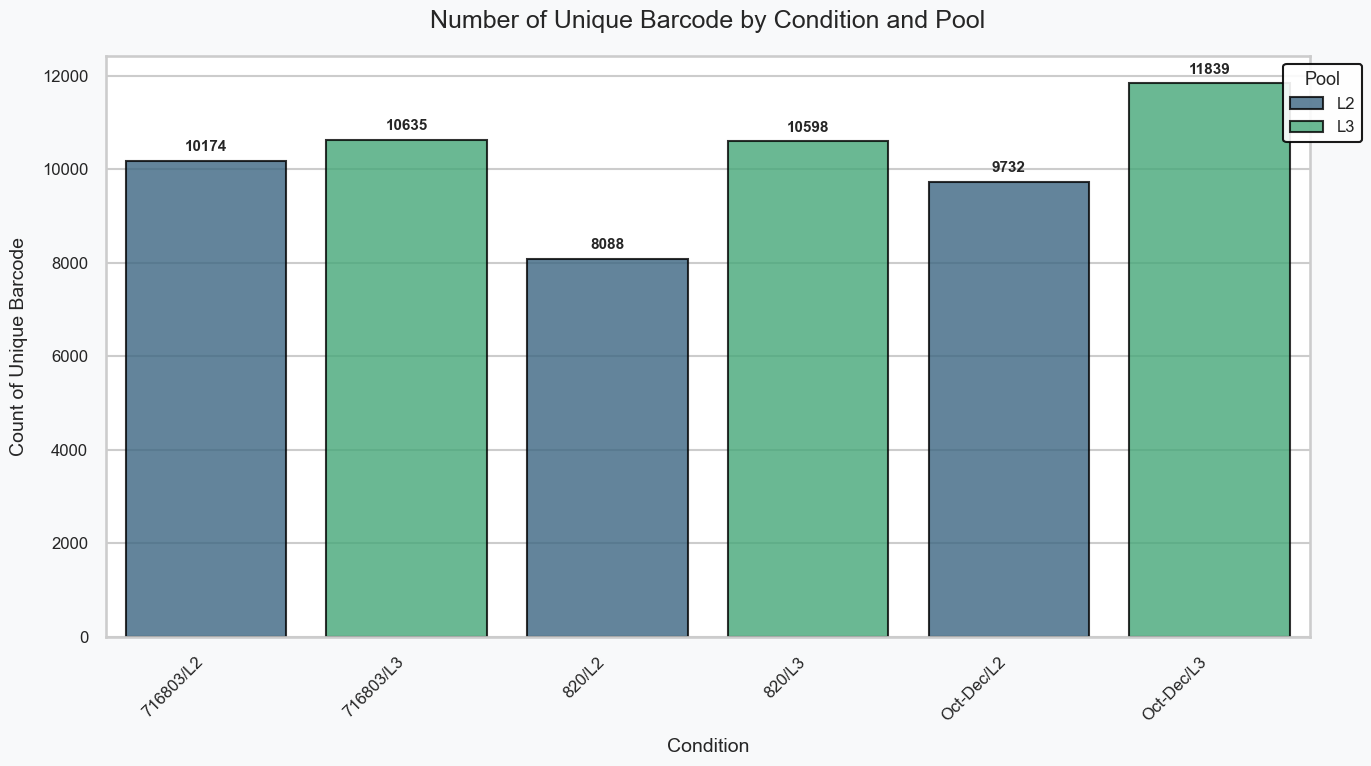

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def plot_unique_values(df, 
                       count_column, 
                       group_by_columns,
                       filters=None,
                       title=None,
                       output_file=None):
    """
    Creates a bar chart showing count of unique values for a specified column
    grouped by one or more other columns, with optional filtering.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data
    count_column : str
        Column name to count unique values from
    group_by_columns : list
        List of column names to group by
    filters : dict, optional
        Dictionary of {column: value} or {column: [value1, value2, ...]} pairs to filter the data
        Example: {'chain': 'TRA'} or {'chain': ['TRA', 'TRB']}
    title : str, optional
        Custom title for the plot (if None, will be auto-generated)
    output_file : str, optional
        Filename to save the plot (if None, will be auto-generated)
    
    Returns:
    --------
    str: Path to the saved output file
    """
    # Create a copy to avoid modifying the original dataframe
    plot_df = df.copy()
    
    # Apply filters if provided
    filter_description = ""
    if filters:
        for column, values in filters.items():
            if column not in df.columns:
                raise ValueError(f"Filter column '{column}' not found in DataFrame")
            
            # Handle both single value and list of values
            if isinstance(values, (list, tuple, set)):
                plot_df = plot_df[plot_df[column].isin(values)]
                filter_values = ', '.join([str(v) for v in values])
                filter_description += f" ({column}={filter_values})"
            else:
                plot_df = plot_df[plot_df[column] == values]
                filter_description += f" ({column}={values})"
    
    # Check if required columns exist
    all_required_cols = group_by_columns + [count_column]
    missing_cols = [col for col in all_required_cols if col not in plot_df.columns]
    if missing_cols:
        raise ValueError(f"DataFrame is missing required columns: {', '.join(missing_cols)}")
    
    # Ensure we have data after filtering
    if plot_df.empty:
        raise ValueError("No data remains after applying filters")
    
    # Auto-generate title if not provided
    if title is None:
        title = f"Number of Unique {count_column.replace('_', ' ').title()} by {' and '.join([col.replace('_', ' ').title() for col in group_by_columns])}{filter_description}"
    
    # Auto-generate output filename if not provided
    if output_file is None:
        # Add filter info to filename
        filter_part = ""
        if filters:
            for column, values in filters.items():
                if isinstance(values, (list, tuple, set)):
                    filter_values = '-'.join([str(v) for v in values])
                    filter_part += f"_{column}-{filter_values}"
                else:
                    filter_part += f"_{column}-{values}"
        
        output_file = f"unique-{count_column}-per-{'_and_'.join(group_by_columns)}{filter_part}.png"
    
    # Count unique values for the specified columns
    counts_df = plot_df.groupby(group_by_columns)[count_column].nunique().reset_index()
    counts_df.columns = group_by_columns + [f'unique_{count_column}']
    
    # Set up plot parameters based on number of grouping columns
    if len(group_by_columns) == 1:
        # Simple bar chart for one grouping column
        sns.set_theme(style="whitegrid", context="talk")
        plt.figure(figsize=(14, 8))
        
        chart = sns.barplot(
            x=group_by_columns[0], 
            y=f'unique_{count_column}', 
            data=counts_df,
            palette="viridis",
            alpha=0.8,
            edgecolor='black',
            linewidth=1.5
        )
        
    elif len(group_by_columns) == 2:
        # Grouped bar chart for two grouping columns
        sns.set_theme(style="whitegrid", context="talk")
        plt.figure(figsize=(14, 8))
        
        palette = sns.color_palette("viridis", n_colors=plot_df[group_by_columns[1]].nunique())
        
        chart = sns.barplot(
            x=group_by_columns[0], 
            y=f'unique_{count_column}', 
            hue=group_by_columns[1], 
            data=counts_df,
            palette=palette,
            alpha=0.8,
            edgecolor='black',
            linewidth=1.5
        )
        
        # Customize the legend
        plt.legend(
            title=group_by_columns[1].replace('_', ' ').title(), 
            title_fontsize=13,
            fontsize=12,
            frameon=True,
            framealpha=0.9,
            edgecolor='black',
            loc='upper right',
            bbox_to_anchor=(1.05, 1),  # Position legend outside plot

        )
        
    else:
        # For 3+ grouping columns, create a facet grid
        sns.set_theme(style="whitegrid", context="notebook")
        
        # Use first two columns for x and hue, remaining ones for facet grid
        grid_cols = min(3, len(group_by_columns) - 2)
        grid_rows = (len(group_by_columns) - 2) // grid_cols
        if (len(group_by_columns) - 2) % grid_cols != 0:
            grid_rows += 1
            
        fig_height = 6 * grid_rows
        fig_width = 6 * grid_cols
        
        g = sns.FacetGrid(
            counts_df, 
            col=group_by_columns[2], 
            row=group_by_columns[3] if len(group_by_columns) > 3 else None,
            margin_titles=True,
            height=5,
            aspect=1.2,
            sharey=True
        )
        
        g.map_dataframe(
            sns.barplot, 
            x=group_by_columns[0], 
            y=f'unique_{count_column}', 
            hue=group_by_columns[1],
            palette="viridis",
            alpha=0.8,
            edgecolor='black'
        )
        
        g.add_legend(title=group_by_columns[1].replace('_', ' ').title())
        g.set_axis_labels(
            group_by_columns[0].replace('_', ' ').title(), 
            f"Unique {count_column.replace('_', ' ').title()} Count"
        )
        g.set_titles(col_template="{col_name}", row_template="{row_name}")
        chart = g
    
    # Enhance the plot
    if len(group_by_columns) <= 2:  # Only for simple and grouped bar charts
        plt.title(title, fontsize=18, pad=20)
        plt.xlabel(group_by_columns[0].replace('_', ' ').title(), fontsize=14, labelpad=10)
        plt.ylabel(f"Count of Unique {count_column.replace('_', ' ').title()}", fontsize=14, labelpad=10)
        plt.xticks(rotation=45, ha='right', fontsize=12)
        plt.yticks(fontsize=12)
        
        # Add value labels on top of each bar
        for p in chart.patches:
            height = p.get_height()
            if not pd.isna(height) and height > 0:  # Only annotate visible bars
                chart.annotate(
                    format(int(height), 'd'),
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold',
                    xytext=(0, 5),
                    textcoords='offset points'
                )
    else:
        # For facet grids, set the super title
        plt.suptitle(title, fontsize=16, y=1.02)
    
    # Adjust layout
    plt.tight_layout()
    
    # Add a subtle background color to the figure
    fig = plt.gcf()
    fig.patch.set_facecolor('#f8f9fa')
    
    # Save the figure with high quality
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f"Figure saved as '{output_file}'")
   
    return chart 

plot_unique_values(df_tcr, count_column="barcode", group_by_columns=["condition", "pool"])


Figure saved as 'unique-cdr3-per-condition_and_pool_chain-TRB.png'


<Axes: title={'center': 'Number of Unique Cdr3 by Condition and Pool (chain=TRB)'}, xlabel='Condition', ylabel='Count of Unique Cdr3'>

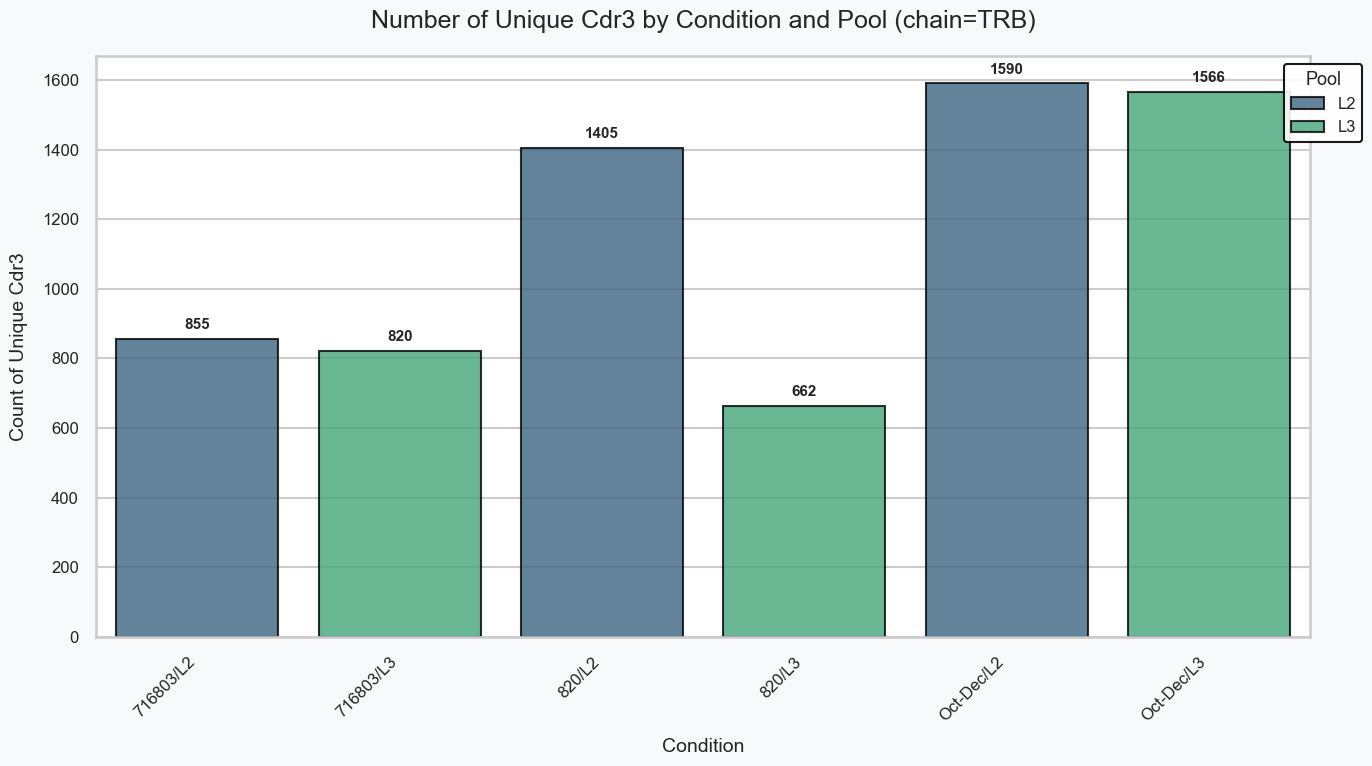

In [7]:
plot_unique_values(df_tcr, count_column="cdr3", group_by_columns=["condition", "pool"], filters={"chain": "TRB"})


Figure saved as 'barcode-per-condition_and_pool_unique.png'
Figure saved as 'barcode-per-condition_and_pool_unique_pct.png'
Figure saved as 'cdr3-per-condition_and_pool_unique_max_pct_chain-TRB.png'


<Axes: title={'center': 'Max Unique (% of Total) Cdr3 by Condition and Pool (chain=TRB)'}, xlabel='Condition', ylabel='Max Unique (% of Total) Cdr3 (%)'>

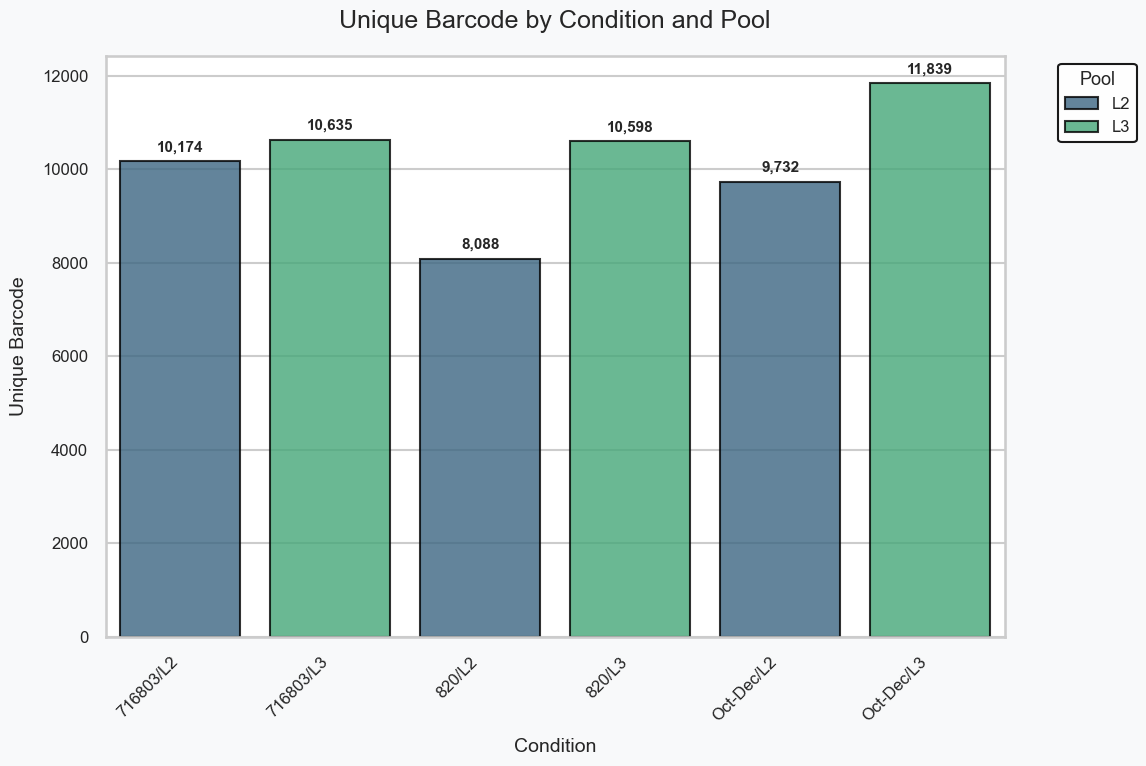

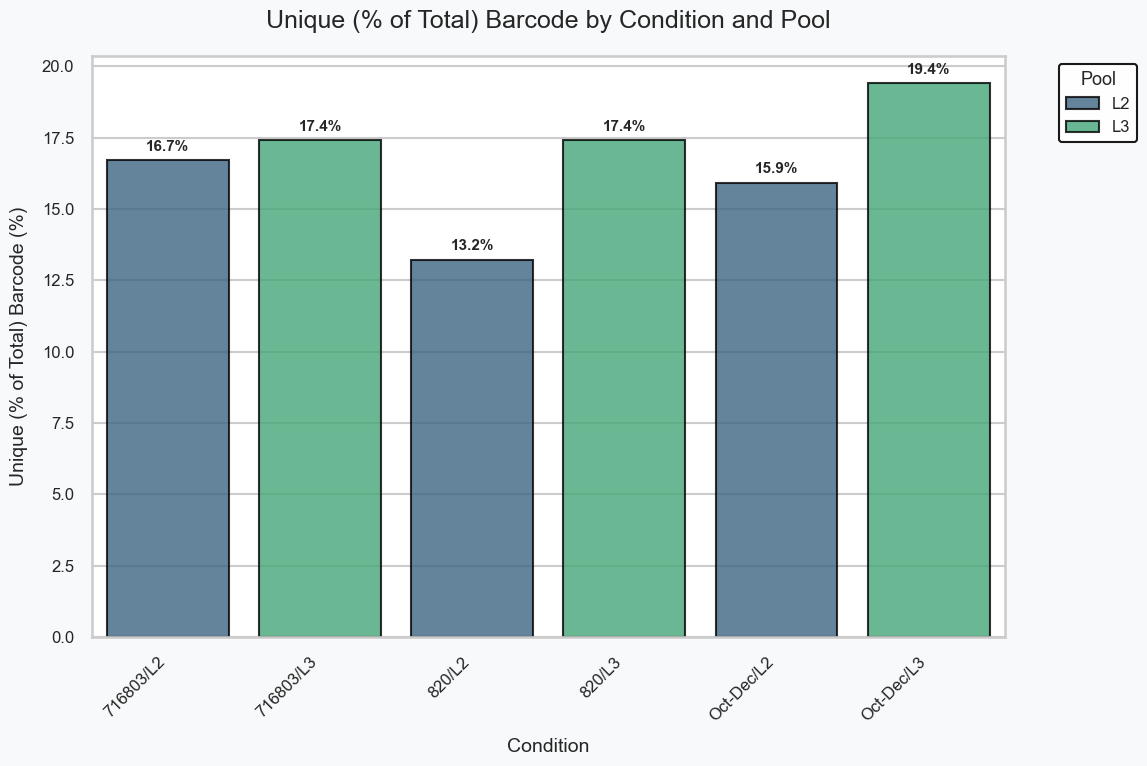

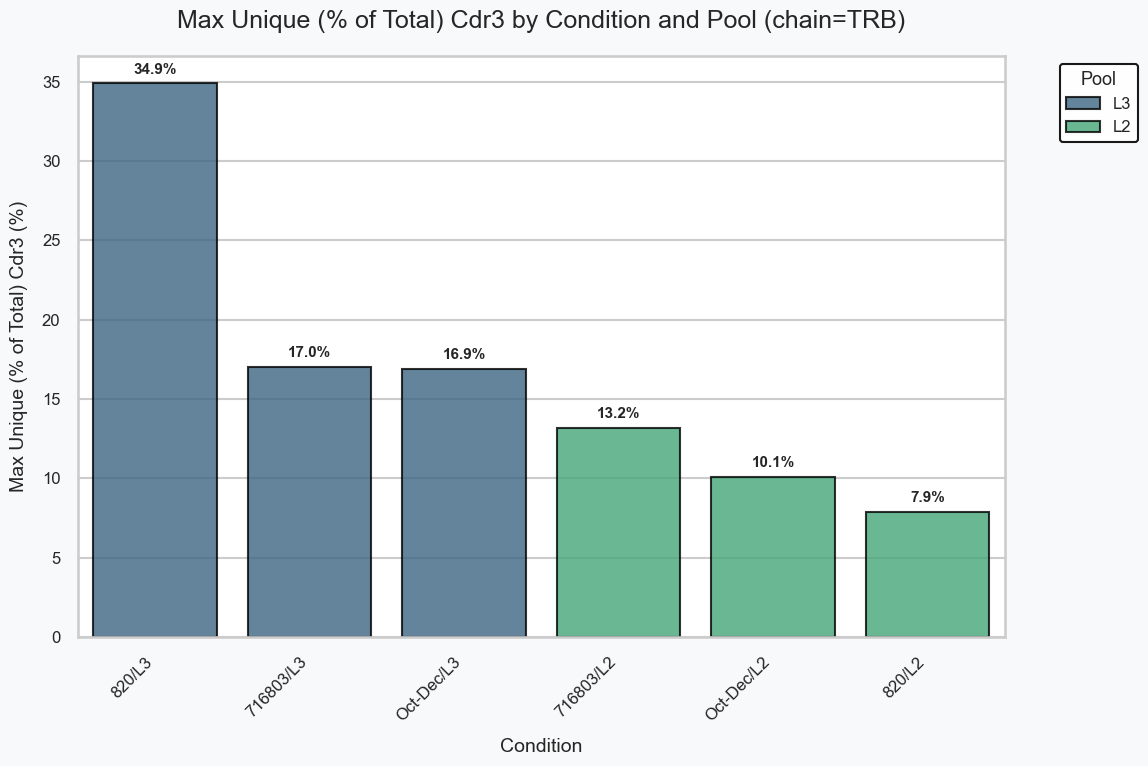

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

def plot_values(df, 
                count_column, 
                group_by_columns,
                count_type='unique',       # 'unique', 'sum', or 'count'
                show_percent=False,        # If True, shows values as % of total in each group
                max_only=False,            # If True, only shows the max value in each group
                filters=None,
                title=None,
                output_file=None):
    """
    Creates a bar chart showing values for a specified column
    grouped by one or more other columns, with optional filtering.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data
    count_column : str
        Column name to analyze values from
    group_by_columns : list
        List of column names to group by
    count_type : str, optional
        Type of counting to perform: 'unique' for unique values count,
        'sum' for sum of values, 'count' for total count
    show_percent : bool, optional
        If True, shows values as percentages of the total in each group
    max_only : bool, optional
        If True and show_percent=True, only shows the maximum value's percentage in each group
    filters : dict, optional
        Dictionary of {column: value} or {column: [value1, value2, ...]} pairs to filter the data
        Example: {'chain': 'TRA'} or {'chain': ['TRA', 'TRB']}
    title : str, optional
        Custom title for the plot (if None, will be auto-generated)
    output_file : str, optional
        Filename to save the plot (if None, will be auto-generated)
    
    Returns:
    --------
    str: Path to the saved output file
    """
    # Create a copy to avoid modifying the original dataframe
    plot_df = df.copy()
    
    # Apply filters if provided
    filter_description = ""
    if filters:
        for column, values in filters.items():
            if column not in df.columns:
                raise ValueError(f"Filter column '{column}' not found in DataFrame")
            
            # Handle both single value and list of values
            if isinstance(values, (list, tuple, set)):
                plot_df = plot_df[plot_df[column].isin(values)]
                filter_values = ', '.join([str(v) for v in values])
                filter_description += f" ({column}={filter_values})"
            else:
                plot_df = plot_df[plot_df[column] == values]
                filter_description += f" ({column}={values})"
    
    # Check if required columns exist
    all_required_cols = group_by_columns + [count_column]
    missing_cols = [col for col in all_required_cols if col not in plot_df.columns]
    if missing_cols:
        raise ValueError(f"DataFrame is missing required columns: {', '.join(missing_cols)}")
    
    # Ensure we have data after filtering
    if plot_df.empty:
        raise ValueError("No data remains after applying filters")
    
    # Determine type of analysis to perform
    if count_type == 'unique':
        value_description = "Unique"
    elif count_type == 'sum':
        value_description = "Sum of"
    elif count_type == 'count':
        value_description = "Count of"
    else:
        raise ValueError("count_type must be 'unique', 'sum', or 'count'")
    
    # Add percentage to description if enabled
    if show_percent:
        if max_only:
            value_description = f"Max {value_description} (% of Total)"
        else:
            value_description = f"{value_description} (% of Total)"
    
    # Auto-generate title if not provided
    if title is None:
        title = f"{value_description} {count_column.replace('_', ' ').title()} by {' and '.join([col.replace('_', ' ').title() for col in group_by_columns])}{filter_description}"
    
    # Auto-generate output filename if not provided
    if output_file is None:
        # Add analysis type and filter info to filename
        mode_part = f"_{count_type}"
        if show_percent:
            if max_only:
                mode_part += "_max_pct"
            else:
                mode_part += "_pct"
            
        filter_part = ""
        if filters:
            for column, values in filters.items():
                if isinstance(values, (list, tuple, set)):
                    filter_values = '-'.join([str(v) for v in values])
                    filter_part += f"_{column}-{filter_values}"
                else:
                    filter_part += f"_{column}-{values}"
        
        output_file = f"{count_column}-per-{'_and_'.join(group_by_columns)}{mode_part}{filter_part}.png"
    
    # Calculate values based on the requested method
    if show_percent and max_only:
        # We need to calculate the max percentage for each group
        
        # First, get a full breakdown of values
        if count_type == 'unique':
            # This is complex for unique values - we need to count occurrences first
            # Create a count for each unique combination of group and value
            value_counts = plot_df.groupby(group_by_columns + [count_column]).size().reset_index(name='value_count')
            
            # Count total unique values for each group
            total_counts = plot_df.groupby(group_by_columns)[count_column].nunique().reset_index()
            total_counts.columns = group_by_columns + ['total_unique']
            
            # Find the max count and value for each group
            max_counts = value_counts.sort_values('value_count', ascending=False).drop_duplicates(group_by_columns)
            
            # Calculate the percentage that max represents of the total
            counts_df = pd.merge(max_counts, total_counts, on=group_by_columns)
            counts_df['percent'] = (counts_df['value_count'] / counts_df['value_count'].sum() * 100).round(1)
            
            # Prepare for plotting
            counts_df = counts_df[group_by_columns + [count_column, 'percent']]
            value_col = 'percent'
            
        elif count_type == 'sum':
            # Break down sums by group and value
            value_sums = plot_df.groupby(group_by_columns + [count_column])[count_column].sum().reset_index()
            value_sums.columns = group_by_columns + [count_column, 'value_sum']
            
            # Calculate total sum for each group
            total_sums = value_sums.groupby(group_by_columns)['value_sum'].sum().reset_index()
            total_sums.columns = group_by_columns + ['total_sum']
            
            # Find max sum for each group
            max_sums = value_sums.sort_values('value_sum', ascending=False).drop_duplicates(group_by_columns)
            
            # Calculate percentage
            counts_df = pd.merge(max_sums, total_sums, on=group_by_columns)
            counts_df['percent'] = (counts_df['value_sum'] / counts_df['total_sum'] * 100).round(1)
            
            # Prepare for plotting
            counts_df = counts_df[group_by_columns + [count_column, 'percent']]
            value_col = 'percent'
            
        else:  # count
            # Count occurrences by group and value
            value_counts = plot_df.groupby(group_by_columns + [count_column]).size().reset_index(name='value_count')
            
            # Calculate total count for each group
            total_counts = value_counts.groupby(group_by_columns)['value_count'].sum().reset_index()
            total_counts.columns = group_by_columns + ['total_count']
            
            # Find max count for each group
            max_counts = value_counts.sort_values('value_count', ascending=False).drop_duplicates(group_by_columns)
            
            # Calculate percentage
            counts_df = pd.merge(max_counts, total_counts, on=group_by_columns)
            counts_df['percent'] = (counts_df['value_count'] / counts_df['total_count'] * 100).round(1)
            
            # Prepare for plotting
            counts_df = counts_df[group_by_columns + [count_column, 'percent']]
            value_col = 'percent'
            
    elif show_percent:
        # Show percentages for all values, not just max
        if count_type == 'unique':
            counts_df = plot_df.groupby(group_by_columns)[count_column].nunique().reset_index()
            counts_df.columns = group_by_columns + ['count']
            
            # Calculate total across all groups
            total = counts_df['count'].sum()
            counts_df['percent'] = (counts_df['count'] / total * 100).round(1)
            value_col = 'percent'
            
        elif count_type == 'sum':
            counts_df = plot_df.groupby(group_by_columns)[count_column].sum().reset_index()
            counts_df.columns = group_by_columns + ['sum']
            
            # Calculate total across all groups
            total = counts_df['sum'].sum()
            counts_df['percent'] = (counts_df['sum'] / total * 100).round(1)
            value_col = 'percent'
            
        else:  # count
            counts_df = plot_df.groupby(group_by_columns)[count_column].count().reset_index()
            counts_df.columns = group_by_columns + ['count']
            
            # Calculate total across all groups
            total = counts_df['count'].sum()
            counts_df['percent'] = (counts_df['count'] / total * 100).round(1)
            value_col = 'percent'
            
    else:
        # Standard counts without percentages
        if count_type == 'unique':
            counts_df = plot_df.groupby(group_by_columns)[count_column].nunique().reset_index()
            counts_df.columns = group_by_columns + ['count']
            value_col = 'count'
            
        elif count_type == 'sum':
            counts_df = plot_df.groupby(group_by_columns)[count_column].sum().reset_index()
            counts_df.columns = group_by_columns + ['sum']
            value_col = 'sum'
            
        else:  # count
            counts_df = plot_df.groupby(group_by_columns)[count_column].count().reset_index()
            counts_df.columns = group_by_columns + ['count']
            value_col = 'count'
    
    # Add extra information for max value if showing max percentages
    if show_percent and max_only:
        counts_df['label'] = counts_df.apply(
            lambda row: f"{row[count_column]}: {row['percent']:.1f}%", axis=1
        )
    
    # Set up plot parameters based on number of grouping columns
    if len(group_by_columns) == 1:
        # Simple bar chart for one grouping column
        sns.set_theme(style="whitegrid", context="talk")
        plt.figure(figsize=(14, 8))
        
        chart = sns.barplot(
            x=group_by_columns[0], 
            y=value_col,
            data=counts_df,
            palette="viridis",
            alpha=0.8,
            edgecolor='black',
            linewidth=1.5
        )
        
    elif len(group_by_columns) == 2:
        # Grouped bar chart for two grouping columns
        sns.set_theme(style="whitegrid", context="talk")
        
        # Create figure with extra space for the legend on the right
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # Check if the column exists in the original dataframe
        if group_by_columns[1] in plot_df.columns:
            palette = sns.color_palette("viridis", n_colors=plot_df[group_by_columns[1]].nunique())
        else:
            palette = "viridis"  # Fallback for derived columns
        
        chart = sns.barplot(
            x=group_by_columns[0], 
            y=value_col,
            hue=group_by_columns[1], 
            data=counts_df,
            palette=palette,
            alpha=0.8,
            edgecolor='black',
            linewidth=1.5,
            ax=ax
        )
        
        # Move legend outside the plot to avoid overlap
        plt.legend(
            title=group_by_columns[1].replace('_', ' ').title(), 
            title_fontsize=13,
            fontsize=12,
            frameon=True,
            framealpha=0.9,
            edgecolor='black',
            bbox_to_anchor=(1.05, 1),  # Position legend outside plot
            loc='upper left'
        )
        
    else:
        # For 3+ grouping columns, create a facet grid
        sns.set_theme(style="whitegrid", context="notebook")
        
        # Use first two columns for x and hue, remaining ones for facet grid
        grid_cols = min(3, len(group_by_columns) - 2)
        grid_rows = (len(group_by_columns) - 2) // grid_cols
        if (len(group_by_columns) - 2) % grid_cols != 0:
            grid_rows += 1
            
        fig_height = 6 * grid_rows
        fig_width = 6 * grid_cols
        
        g = sns.FacetGrid(
            counts_df, 
            col=group_by_columns[2], 
            row=group_by_columns[3] if len(group_by_columns) > 3 else None,
            margin_titles=True,
            height=5,
            aspect=1.2,
            sharey=True
        )
        
        g.map_dataframe(
            sns.barplot, 
            x=group_by_columns[0], 
            y=value_col,
            hue=group_by_columns[1],
            palette="viridis",
            alpha=0.8,
            edgecolor='black'
        )
        
        # Place legend at the top right outside the plot
        g.add_legend(
            title=group_by_columns[1].replace('_', ' ').title(),
            bbox_to_anchor=(1.05, 1),
            loc='upper left'
        )
        
        g.set_axis_labels(
            group_by_columns[0].replace('_', ' ').title(), 
            f"{value_description} {count_column.replace('_', ' ').title()} (%)" if show_percent else f"{value_description} {count_column.replace('_', ' ').title()}"
        )
        g.set_titles(col_template="{col_name}", row_template="{row_name}")
        chart = g
    
    # Enhance the plot
    if len(group_by_columns) <= 2:  # Only for simple and grouped bar charts
        plt.title(title, fontsize=18, pad=20)
        plt.xlabel(group_by_columns[0].replace('_', ' ').title(), fontsize=14, labelpad=10)
        
        # Y-axis label with appropriate units
        y_label = f"{value_description} {count_column.replace('_', ' ').title()}"
        if show_percent:
            y_label += " (%)"
        plt.ylabel(y_label, fontsize=14, labelpad=10)
        
        plt.xticks(rotation=45, ha='right', fontsize=12)
        plt.yticks(fontsize=12)
        
        # Add value labels on top of each bar with appropriate formatting
        for p in chart.patches:
            height = p.get_height()
            if not pd.isna(height) and height > 0:  # Only annotate visible bars
                if show_percent:
                    # Format as percentage with 1 decimal place
                    value_text = f"{height:.1f}%"
                else:
                    # Format as integer
                    value_text = f"{int(height):,d}"
                    
                # For max only with labels, include the value label
                #if show_percent and max_only:
                #    idx = chart.patches.index(p)
                #    if idx < len(counts_df):
                #        row = counts_df.iloc[idx]
                #        if 'label' in row:
                #            value_text = row['label']
                
                chart.annotate(
                    value_text,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold',
                    xytext=(0, 5),
                    textcoords='offset points'
                )
    else:
        # For facet grids, set the super title
        plt.suptitle(title, fontsize=16, y=1.02)
    
    # Adjust layout to make room for the legend
    if len(group_by_columns) == 2:
        plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space on right for legend
    else:
        plt.tight_layout()
    
    # Add a subtle background color to the figure
    fig = plt.gcf()
    fig.patch.set_facecolor('#f8f9fa')
    
    # Save the figure with high quality
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f"Figure saved as '{output_file}'")
    return chart 

# Basic usage - absolute counts
plot_values(
    df_tcr, 
    count_column='barcode', 
    group_by_columns=['condition', 'pool'],
    count_type='unique'
)

# Show each group's count as percentage of total
plot_values(
    df_tcr, 
    count_column='barcode', 
    group_by_columns=['condition', 'pool'],
    count_type='unique',
    show_percent=True  # Y-axis will show percentages
)

# Show only the max value's percentage in each group
plot_values(
    df_tcr, 
    count_column='cdr3', 
    group_by_columns=['condition', 'pool'],

    show_percent=True,
    max_only=True,  # Only show the max value's percentage
    filters={'chain': 'TRB'}
)